# Dimensionality Reduction and Final Model

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import Row
from pyspark.sql.functions import min, max, xxhash64, col, when, udf
from functools import reduce
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder, Imputer
from pyspark.ml.classification import RandomForestClassifier, RandomForestClassificationModel, LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics
from pyspark.storagelevel import StorageLevel
from pyspark.ml.classification import GBTClassifier

from pyspark.ml.linalg import Vectors as MLVectors, VectorUDT
from pyspark.mllib.linalg import Vectors as MLLibVectors
from pyspark.mllib.linalg.distributed import RowMatrix
from pyspark.mllib.linalg import DenseMatrix

import os
job_scratch = os.environ["TMPDIR"]  # /scratch/lcheng7/job_#
spark_tmp = os.path.join(job_scratch, "spark_tmp")
os.makedirs(spark_tmp, exist_ok=True)

# Change on creation
TOTAL_CORES = 8
TOTAL_MEM_GB = 200
DRIVER_MEM_GB = 12 # Fixed

EXEC_INSTANCES = TOTAL_CORES - 1
EXEC_MEM_GB = int((TOTAL_MEM_GB - DRIVER_MEM_GB) / EXEC_INSTANCES)

spark = (
    SparkSession.builder
    .appName("fhvhv-model")
    .config("spark.driver.memory", f"{DRIVER_MEM_GB}g")
    .config("spark.local.dir", spark_tmp)
    .config("spark.executor.instances", str(EXEC_INSTANCES))
    .config("spark.executor.memory", f"{EXEC_MEM_GB}g")
    .config("spark.sql.shuffle.partitions", str(EXEC_INSTANCES * 3))
    .config("spark.default.parallelism", str(EXEC_INSTANCES * 3))
    .getOrCreate()
)

print("TMPDIR =", job_scratch)
print("spark.local.dir =", spark.sparkContext.getConf().get("spark.local.dir"))
print("parallelism =", spark.sparkContext.defaultParallelism)
print("executors:", EXEC_INSTANCES, "executor_mem_gb:", EXEC_MEM_GB)

Matplotlib created a temporary cache directory at /scratch/lcheng7/job_47461558/matplotlib-gi7eytz1 because the default path (/home/jovyan/.cache/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


TMPDIR = /scratch/lcheng7/job_47461558
spark.local.dir = /scratch/lcheng7/job_47461558/spark_tmp
parallelism = 21
executors: 7 executor_mem_gb: 26


In [2]:
print("MASTER =", spark.sparkContext.master)
print("DRIVER MEM =", spark.sparkContext.getConf().get("spark.driver.memory"))
print("EXEC INSTANCES =", spark.sparkContext.getConf().get("spark.executor.instances"))

MASTER = local[*]
DRIVER MEM = 12g
EXEC INSTANCES = 7


In [3]:
train_df = spark.read.parquet("train_split")
test_df = spark.read.parquet("test_split")

## SVD (Singular Value Decomposition)

In [4]:
from pyspark.mllib.linalg import Vectors as MLLibVectors
from pyspark.mllib.linalg.distributed import RowMatrix

# Convert train_df "features" (pyspark.ml.linalg) to RDD of mllib Vectors for RowMatrix
def ml_to_mllib(v):
    return MLLibVectors.dense(v.toArray())

features_rdd = train_df.select("features").rdd.map(lambda row: ml_to_mllib(row.features))
row_matrix = RowMatrix(features_rdd)

num_features = len(train_df.first().features)
# keeping k as min of features or 20
k = 20 if num_features >= 20 else num_features  

svd = row_matrix.computeSVD(k, computeU=True)

# Results: U (left singular vectors), s (singular values), V (right singular vectors)
print("Number of singular values (k):", len(svd.s))
print("Singular values (first 10):", svd.s[:10] if hasattr(svd.s, '__getitem__') else svd.s.toArray()[:10])
print("V shape (right singular vectors):", svd.V.numRows, "x", svd.V.numCols)


Number of singular values (k): 20
Singular values (first 10): [28901.33477397 26745.90589668 18974.3760086  16838.44472647
 14157.41108726 13831.47166967 13676.576221   13300.71944635
 12962.81255853 12333.12695947]
V shape (right singular vectors): 39 x 20


In [5]:
from pyspark.sql.types import StructType, StructField, IntegerType, ArrayType, DoubleType

# Save V (right singular vectors) - needed to project any row onto the SVD space
v_rows, v_cols = int(svd.V.numRows), int(svd.V.numCols)
# Use a list comprehension to force conversion to standard Python floats
v_values = [float(x) for x in svd.V.values] 

schema_v = StructType([
    StructField("numRows", IntegerType()),
    StructField("numCols", IntegerType()),
    StructField("values", ArrayType(DoubleType()))
])

spark.createDataFrame([(v_rows, v_cols, v_values)], schema_v) \
    .write.mode("overwrite").parquet("processed_data/svd_V")


# Save s (singular values)
s_arr = svd.s.toArray() if hasattr(svd.s, "toArray") else svd.s
# Force conversion of every element to a Python float
s_values = [float(x) for x in s_arr]

schema_s = StructType([
    StructField("singular_values", ArrayType(DoubleType()))
])

spark.createDataFrame([(s_values,)], schema_s) \
    .write.mode("overwrite").parquet("processed_data/svd_s")

In [6]:
from pyspark.mllib.linalg import DenseMatrix, DenseVector
df_v = spark.read.parquet("processed_data/svd_V")
r = df_v.first()
svd_V = DenseMatrix(r.numRows, r.numCols, r.values)
df_s = spark.read.parquet("processed_data/svd_s")
svd_s = DenseVector(df_s.first().singular_values)


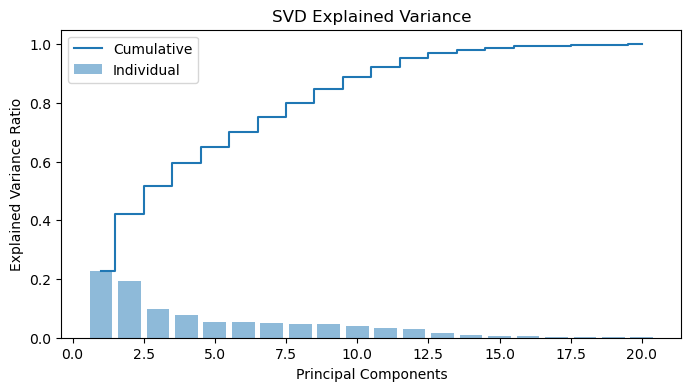

Total Variance Explained by 20 components: 100.00%


In [7]:
# Load the singular values
df_s = spark.read.parquet("processed_data/svd_s")
s_values = np.array(df_s.first().singular_values)

# Calculate Explained Variance Ratio
eigenvalues = s_values**2
variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(variance_ratio)

plt.figure(figsize=(8, 4))
plt.bar(range(1, len(variance_ratio) + 1), variance_ratio, alpha=0.5, align='center', label='Individual')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid', label='Cumulative')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc='best')
plt.title('SVD Explained Variance')
plt.show()

print(f"Total Variance Explained by 20 components: {cumulative_variance[-1]*100:.2f}%")

In [4]:
df_v = spark.read.parquet("processed_data/svd_V")
r = df_v.first()

V_mat = np.array(r.values).reshape((r.numRows, r.numCols), order='F')

sc = spark.sparkContext
broadcast_V = sc.broadcast(V_mat)

def project_features(features):
    # Convert Spark Vector to NumPy array, multiply by V, and convert back
    feat_array = features.toArray()
    projected = np.dot(feat_array, broadcast_V.value)
    return MLVectors.dense(projected)

project_udf = udf(project_features, VectorUDT())

train_reduced_df = train_df.withColumn("features", project_udf(col("features"))) \
                           .select("features", "label", "class_weight")

test_reduced_df = test_df.withColumn("features", project_udf(col("features"))) \
                         .select("features", "label", "class_weight")

print(f"Original dim: {r.numRows} -> Reduced dim: {r.numCols}")
train_reduced_df.select("features", "label", "class_weight").show(3, truncate=False)

Original dim: 39 -> Reduced dim: 20
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+------------+
|features                                                                                                                                                                                                                                                                                                                                                                                                      |label|class_weight|
+---------------------------------------------------------------------------------------------------------------------------

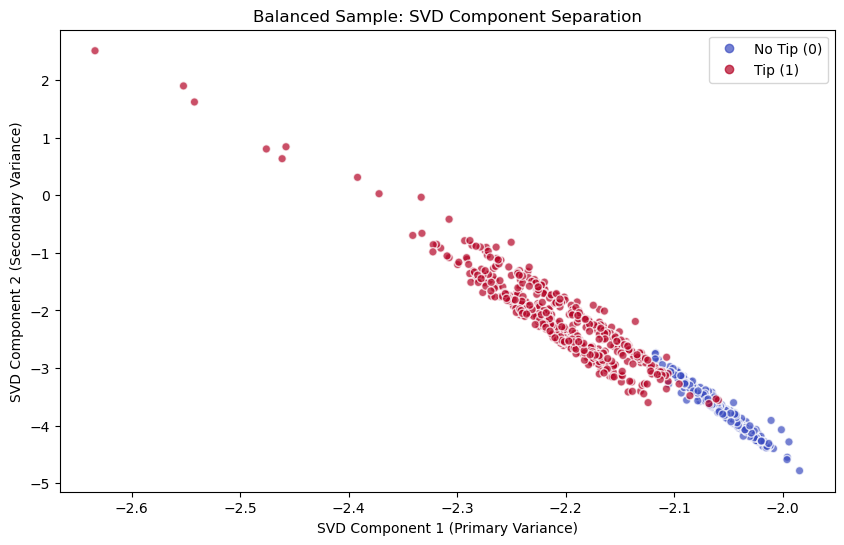

In [10]:
# 1. Take a balanced sample: 500 of each class
sample_0 = train_reduced_df.filter(col("label") == 0).limit(500).toPandas()
sample_1 = train_reduced_df.filter(col("label") == 1).limit(500).toPandas()
sample_pd = pd.concat([sample_0, sample_1])

# 2. Extract SVD components
sample_pd['svd_1'] = sample_pd['features'].apply(lambda v: v[0])
sample_pd['svd_2'] = sample_pd['features'].apply(lambda v: v[1])

# 3. Plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(sample_pd['svd_1'], sample_pd['svd_2'], 
                      c=sample_pd['label'], cmap='coolwarm', alpha=0.7, edgecolors='w')

plt.legend(handles=scatter.legend_elements()[0], labels=["No Tip (0)", "Tip (1)"])
plt.xlabel('SVD Component 1 (Primary Variance)')
plt.ylabel('SVD Component 2 (Secondary Variance)')
plt.title('Balanced Sample: SVD Component Separation')
plt.show()

In [11]:
# 1. Initialize the Model
# We use the reduced features to predict the label
lr = LogisticRegression(featuresCol="features", 
                        labelCol="label", 
                        weightCol="class_weight",
                        maxIter=10)

# 2. Train (Fit) the model
print("Training Logistic Regression on reduced SVD features...")
lr_model = lr.fit(train_reduced_df)

# 3. Make Predictions on the Test Set
predictions = lr_model.transform(test_reduced_df)

Training Logistic Regression on reduced SVD features...


In [12]:
# 4. Evaluate the Model
# Check Accuracy
evaluator_acc = MulticlassClassificationEvaluator(metricName="accuracy")
accuracy = evaluator_acc.evaluate(predictions)

# Check Area Under ROC (Good for imbalanced data)
evaluator_roc = BinaryClassificationEvaluator(rawPredictionCol="rawPrediction")
auroc = evaluator_roc.evaluate(predictions)

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Area Under ROC: {auroc:.4f}")

# Show a few predictions vs actual labels
predictions.select("features", "label", "prediction", "probability").show(5)

Test Accuracy: 0.6001
Area Under ROC: 0.6368
+--------------------+-----+----------+--------------------+
|            features|label|prediction|         probability|
+--------------------+-----+----------+--------------------+
|[-1.9895547793396...|    0|       0.0|[0.84510980336906...|
|[-2.0082675665379...|    0|       0.0|[0.81183282188694...|
|[-2.0783248022604...|    0|       0.0|[0.83746506701068...|
|[-2.0167557116206...|    0|       0.0|[0.81498117671155...|
|[-2.0083351641606...|    0|       0.0|[0.85443456194817...|
+--------------------+-----+----------+--------------------+
only showing top 5 rows



In [13]:
# Save the model 
model_path = "processed_data/lr_model_svd_20"
lr_model.write().overwrite().save(model_path)

print(f"Model saved successfully to {model_path}")

Model saved successfully to processed_data/lr_model_svd_20


In [14]:
# Get the weights the model assigned to each of the 20 SVD components
weights = lr_model.coefficients.toArray()
abs_weights = np.abs(weights)

# Create a small summary
feat_importance = pd.DataFrame({
    'SVD_Component': [f"PC_{i+1}" for i in range(len(weights))],
    'Weight': weights,
    'Absolute_Importance': abs_weights
}).sort_values(by='Absolute_Importance', ascending=False)

print("Top 5 Most Influential SVD Components:")
print(feat_importance.head(5))

Top 5 Most Influential SVD Components:
   SVD_Component    Weight  Absolute_Importance
0           PC_1 -0.541159             0.541159
16         PC_17  0.281200             0.281200
12         PC_13 -0.272746             0.272746
18         PC_19 -0.265132             0.265132
10         PC_11  0.259980             0.259980


In [5]:
train_small = train_reduced_df.sample(False, 0.2, seed=42)
test_small = test_reduced_df.sample(False, 0.2, seed=42)

train_small.write.mode("overwrite").parquet("processed_data/train_small_sample")
test_small.write.mode("overwrite").parquet("processed_data/test_small_sample")

In [6]:
train_small = spark.read.parquet("processed_data/train_small_sample")
test_small = spark.read.parquet("processed_data/test_small_sample")

print("train_small:", train_small.count())
print("test_small :", test_small.count())

train_small: 35763182
test_small : 8945069


In [8]:
from xgboost.spark import SparkXGBClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

xgb = SparkXGBClassifier(
    features_col="features",
    label_col="label",
    num_workers=8,
    max_depth=6,
    n_estimators=100,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    seed=42
)

print("Training XGBoost Classifier on sampled reduced SVD features...")
xgb_model = xgb.fit(train_small)

Training XGBoost Classifier on sampled reduced SVD features...


2026-03-17 19:25:33,740 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 8 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'seed': 42, 'eval_metric': 'logloss', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-17 19:27:44,774 INFO XGBoost-PySpark: _fit Finished xgboost training!


In [9]:
# Predictions
train_preds_xgb = xgb_model.transform(train_small)
test_preds_xgb = xgb_model.transform(test_small)

# Evaluators
roc_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

pr_eval = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderPR"
)

print("XGBoost Classifier Results")
print("Train ROC-AUC:", roc_eval.evaluate(train_preds_xgb))
print("Test  ROC-AUC:", roc_eval.evaluate(test_preds_xgb))
print("Train PR-AUC :", pr_eval.evaluate(train_preds_xgb))
print("Test  PR-AUC :", pr_eval.evaluate(test_preds_xgb))

XGBoost Classifier Results
Train ROC-AUC: 0.6589656189637101
Test  ROC-AUC: 0.6583530603651022
Train PR-AUC : 0.2551664773934754
Test  PR-AUC : 0.254146820866342


In [10]:
test_preds_xgb.select("label", "prediction", "probability").show(20, truncate=False)

+-----+----------+------------------------------------------+
|label|prediction|probability                               |
+-----+----------+------------------------------------------+
|0    |0.0       |[0.9933716058731079,0.006628366187214851] |
|0    |0.0       |[0.9938379526138306,0.006162029691040516] |
|0    |0.0       |[0.9948747754096985,0.0051252455450594425]|
|0    |0.0       |[0.9945211410522461,0.005478856153786182] |
|0    |0.0       |[0.9864182472229004,0.013581735081970692] |
|0    |0.0       |[0.9957911372184753,0.004208853468298912] |
|0    |0.0       |[0.996752142906189,0.0032478354405611753] |
|0    |0.0       |[0.9966076016426086,0.0033924165181815624]|
|0    |0.0       |[0.9959505200386047,0.004049486946314573] |
|0    |0.0       |[0.9968026280403137,0.003197342623025179] |
|0    |0.0       |[0.9918569922447205,0.008143028244376183] |
|0    |0.0       |[0.9930086135864258,0.00699140690267086]  |
|0    |0.0       |[0.9925674796104431,0.007432522717863321] |
|0    |0

In [17]:
param_grid = [
    {"max_depth": 8, "n_estimators": 150, "learning_rate": 0.05},
    {"max_depth": 10, "n_estimators": 100, "learning_rate": 0.05},
    {"max_depth": 10, "n_estimators": 150, "learning_rate": 0.03},
    {"max_depth": 8, "n_estimators": 200, "learning_rate": 0.03},
]

results = []

for params in param_grid:
    print("\nTesting params:", params)

    xgb = SparkXGBClassifier(
        features_col="features",
        label_col="label",
        num_workers=8,
        max_depth=params["max_depth"],
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        seed=42
    )

    model = xgb.fit(train_small)

    preds = model.transform(test_small)

    roc = roc_eval.evaluate(preds)
    pr = pr_eval.evaluate(preds)

    print(f"ROC-AUC: {roc:.4f}, PR-AUC: {pr:.4f}")

    results.append({
        "params": params,
        "roc_auc": roc,
        "pr_auc": pr
    })

# sort by PR-AUC (more important for imbalance)
results_sorted = sorted(results, key=lambda x: x["pr_auc"], reverse=True)

print("\n=== BEST CONFIG ===")
print(results_sorted[0])


Testing params: {'max_depth': 8, 'n_estimators': 150, 'learning_rate': 0.05}


2026-03-17 20:01:42,515 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 8 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 0.8, 'seed': 42, 'eval_metric': 'logloss', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 150}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-17 20:05:31,714 INFO XGBoost-PySpark: _fit Finished xgboost training!


ROC-AUC: 0.6691, PR-AUC: 0.2651

Testing params: {'max_depth': 10, 'n_estimators': 100, 'learning_rate': 0.05}


2026-03-17 20:06:36,385 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 8 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 10, 'subsample': 0.8, 'seed': 42, 'eval_metric': 'logloss', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-17 20:10:08,568 INFO XGBoost-PySpark: _fit Finished xgboost training!


ROC-AUC: 0.6756, PR-AUC: 0.2742

Testing params: {'max_depth': 10, 'n_estimators': 150, 'learning_rate': 0.03}


2026-03-17 20:11:13,971 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 8 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.03, 'max_depth': 10, 'subsample': 0.8, 'seed': 42, 'eval_metric': 'logloss', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 150}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-17 20:16:18,959 INFO XGBoost-PySpark: _fit Finished xgboost training!


ROC-AUC: 0.6746, PR-AUC: 0.2729

Testing params: {'max_depth': 8, 'n_estimators': 200, 'learning_rate': 0.03}


2026-03-17 20:17:29,795 INFO XGBoost-PySpark: _fit Running xgboost-2.0.3 on 8 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.03, 'max_depth': 8, 'subsample': 0.8, 'seed': 42, 'eval_metric': 'logloss', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 200}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
2026-03-17 20:22:25,927 INFO XGBoost-PySpark: _fit Finished xgboost training!


ROC-AUC: 0.6654, PR-AUC: 0.2607

=== BEST CONFIG ===
{'params': {'max_depth': 10, 'n_estimators': 100, 'learning_rate': 0.05}, 'roc_auc': 0.6756327417459979, 'pr_auc': 0.2741594354490475}


In [18]:
from pyspark.sql.functions import col, when
from pyspark.ml.functions import vector_to_array
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

best_preds = xgb_model.transform(test_small)

# convert vector probability column into a regular array column
best_preds = best_preds.withColumn(
    "prob_array",
    vector_to_array(col("probability"))
)

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
rows = []

for t in thresholds:
    temp = best_preds.withColumn(
        "custom_prediction",
        when(col("prob_array")[1] > t, 1).otherwise(0)
    )
    
    tp = temp.filter((col("label") == 1) & (col("custom_prediction") == 1)).count()
    tn = temp.filter((col("label") == 0) & (col("custom_prediction") == 0)).count()
    fp = temp.filter((col("label") == 0) & (col("custom_prediction") == 1)).count()
    fn = temp.filter((col("label") == 1) & (col("custom_prediction") == 0)).count()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    
    rows.append([t, tp, tn, fp, fn, precision, recall, accuracy, f1])

threshold_df = pd.DataFrame(
    rows,
    columns=["threshold", "TP", "TN", "FP", "FN", "precision", "recall", "accuracy", "f1"]
)

print("Threshold comparison:")
print(threshold_df.sort_values("f1", ascending=False))

chosen_threshold = float(threshold_df.sort_values("f1", ascending=False).iloc[0]["threshold"])
print("\nChosen threshold:", chosen_threshold)

final_preds = best_preds.withColumn(
    "custom_prediction",
    when(col("prob_array")[1] > chosen_threshold, 1).otherwise(0)
)

tp = final_preds.filter((col("label") == 1) & (col("custom_prediction") == 1)).count()
tn = final_preds.filter((col("label") == 0) & (col("custom_prediction") == 0)).count()
fp = final_preds.filter((col("label") == 0) & (col("custom_prediction") == 1)).count()
fn = final_preds.filter((col("label") == 1) & (col("custom_prediction") == 0)).count()

print("\nFinal Confusion Matrix")
print(f"TP: {tp}")
print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")

Threshold comparison:
   threshold       TP       TN       FP       FN  precision    recall  \
2       0.15   922962  4290456  3253688   477963   0.220981  0.658823   
3       0.20   591663  5882624  1661520   809262   0.262590  0.422337   
1       0.10  1266806  1805356  5738788   134119   0.180828  0.904264   
0       0.05  1396540   211677  7332467     4385   0.159988  0.996870   
4       0.25   323904  6780705   763439  1077021   0.297886  0.231207   
5       0.30   104024  7344841   199303  1296901   0.342943  0.074254   

   accuracy        f1  
2  0.582826  0.330955  
3  0.723783  0.323834  
1  0.343448  0.301387  
0  0.179788  0.275725  
4  0.794249  0.260345  
5  0.832734  0.122076  

Chosen threshold: 0.15

Final Confusion Matrix
TP: 922962
TN: 4290456
FP: 3253688
FN: 477963


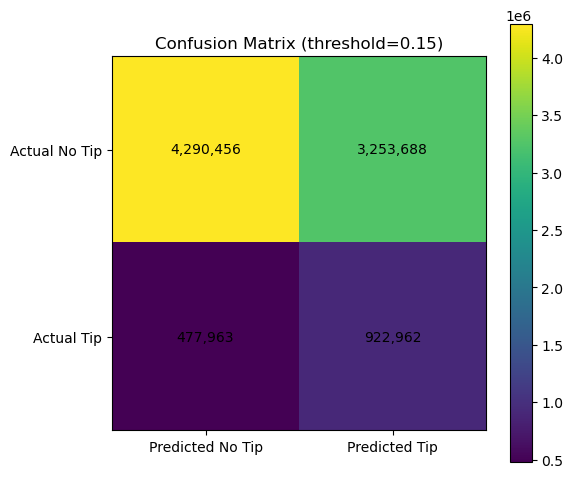

In [19]:
cm = np.array([
    [tn, fp],
    [fn, tp]
])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest")
plt.colorbar(im)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Predicted No Tip", "Predicted Tip"])
ax.set_yticklabels(["Actual No Tip", "Actual Tip"])
ax.set_title(f"Confusion Matrix (threshold={chosen_threshold:.2f})")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center")

plt.tight_layout()
plt.show()